In [1]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/rps.zip \
    -O /tmp/rps.zip

!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/rps-test-set.zip \
    -O /tmp/rps-test-set.zip

--2025-03-06 00:10:49--  https://storage.googleapis.com/learning-datasets/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.186.123, 142.250.185.123, 142.250.185.187, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.186.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘/tmp/rps.zip’

/tmp/rps.zip        100%[===================>] 191.38M  9.83MB/s    in 19s     

2025-03-06 00:11:09 (9.82 MB/s) - ‘/tmp/rps.zip’ saved [200682221/200682221]

--2025-03-06 00:11:09--  https://storage.googleapis.com/learning-datasets/rps-test-set.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.185.123, 216.58.212.187, 142.250.185.251, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.185.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29516758 (28M) [application/zip]
Saving to: ‘/tmp/rps-test-set.zip’

/t

In [2]:
import os
import zipfile

local_zip = '/tmp/rps.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/')
zip_ref.close()

local_zip = '/tmp/rps-test-set.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/')
zip_ref.close()

In [3]:
rock_dir = os.path.join('/tmp/rps/rock')
paper_dir = os.path.join('/tmp/rps/paper')
scissors_dir = os.path.join('/tmp/rps/scissors')

print('total training rock images:', len(os.listdir(rock_dir)))
print('total training paper images:', len(os.listdir(paper_dir)))
print('total training scissors images:', len(os.listdir(scissors_dir)))

rock_files = os.listdir(rock_dir)
print(rock_files[:10])

paper_files = os.listdir(paper_dir)
print(paper_files[:10])

scissors_files = os.listdir(scissors_dir)
print(scissors_files[:10])

total training rock images: 840
total training paper images: 840
total training scissors images: 840
['rock04-002.png', 'rock01-114.png', 'rock06ck02-026.png', 'rock04-108.png', 'rock02-040.png', 'rock04-010.png', 'rock03-009.png', 'rock07-k03-001.png', 'rock04-036.png', 'rock03-045.png']
['paper04-075.png', 'paper07-048.png', 'paper02-048.png', 'paper04-019.png', 'paper07-118.png', 'paper02-074.png', 'paper07-032.png', 'paper06-101.png', 'paper05-053.png', 'paper03-015.png']
['testscissors03-009.png', 'testscissors03-008.png', 'scissors04-050.png', 'scissors03-001.png', 'testscissors03-043.png', 'scissors01-114.png', 'scissors01-077.png', 'scissors01-067.png', 'testscissors03-017.png', 'scissors03-057.png']


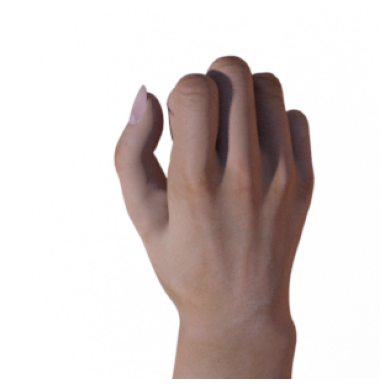

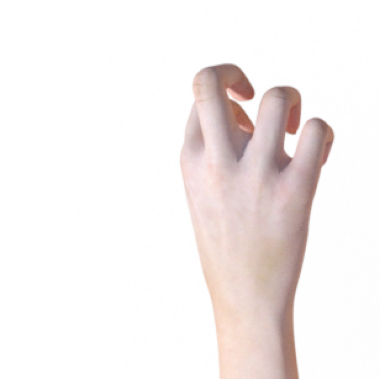

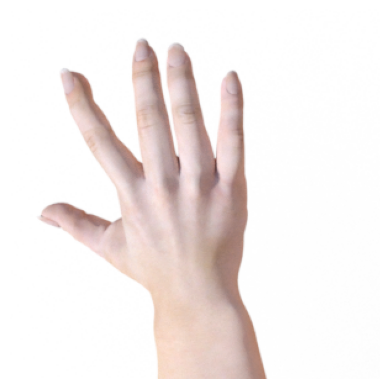

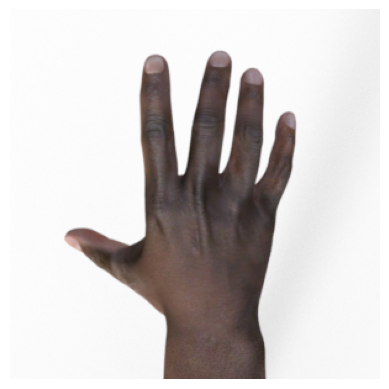

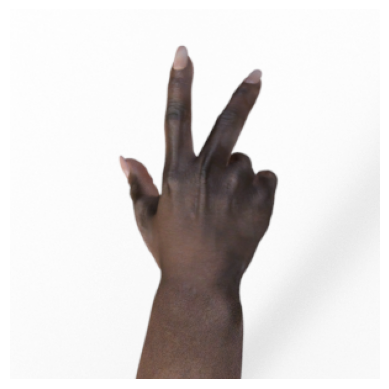

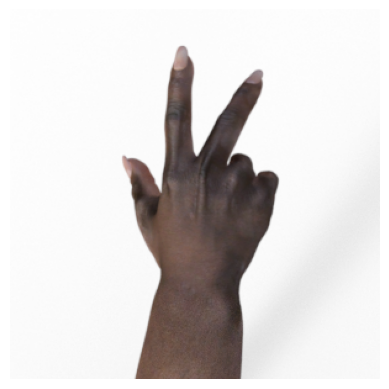

In [4]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pic_index = 2

next_rock = [os.path.join(rock_dir, fname)
                for fname in rock_files[pic_index-2:pic_index]]
next_paper = [os.path.join(paper_dir, fname)
                for fname in paper_files[pic_index-2:pic_index]]
next_scissors = [os.path.join(scissors_dir, fname)
                for fname in scissors_files[pic_index-2:pic_index]]

for i, img_path in enumerate(next_rock+next_paper+next_scissors):
  #print(img_path)
  img = mpimg.imread(img_path)
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAINING_DIR = "/tmp/rps/"
training_datagen = ImageDataGenerator(
      rescale = 1./255,
	    rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

VALIDATION_DIR = "/tmp/rps-test-set/"
validation_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = training_datagen.flow_from_directory(
	TRAINING_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

validation_generator = validation_datagen.flow_from_directory(
	VALIDATION_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 150x150 with 3 bytes color
    # This is the first convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])


model.summary()

model.compile(loss = 'categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

history = model.fit(train_generator, epochs=25, steps_per_epoch=20, validation_data = validation_generator, verbose = 1, validation_steps=3)

model.save("rps.h5")


2025-03-06 00:11:15.274756: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-06 00:11:15.278914: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-06 00:11:15.288595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741216275.304166   75402 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741216275.309016   75402 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-06 00:11:15.326795: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.


/home/dang-minh-nguyen/Desktop/Repositories/Kaggle-Projects/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-03-06 00:11:18.243272: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Epoch 1/25


2025-03-06 00:11:21.574175: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 706535424 exceeds 10% of free system memory.
2025-03-06 00:11:23.321883: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 353267712 exceeds 10% of free system memory.
2025-03-06 00:11:23.322039: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 706535424 exceeds 10% of free system memory.


 1/20 ━━━━━━━━━━━━━━━━━━━━ 1:25 5s/step - accuracy: 0.2857 - loss: 1.1091

2025-03-06 00:11:24.325248: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 706535424 exceeds 10% of free system memory.
2025-03-06 00:11:26.127325: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 353267712 exceeds 10% of free system memory.


20/20 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.3399 - loss: 1.2294 - val_accuracy: 0.3333 - val_loss: 1.0962
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.3532 - loss: 1.1002 - val_accuracy: 0.3333 - val_loss: 1.0976
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.3739 - loss: 1.0924 - val_accuracy: 0.7231 - val_loss: 0.9766
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.5049 - loss: 1.0234 - val_accuracy: 0.6640 - val_loss: 0.7553
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.4130 - loss: 1.0840 - val_accuracy: 0.7473 - val_loss: 0.7552
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.5685 - loss: 0.8834 - val_accuracy: 0.7554 - val_loss: 0.5390
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.6675 - loss: 0.7002 - val_accuracy: 0.7043 - val_loss: 0.4240
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.6961 - loss: 0.6477 - val_accuracy: 0.6667 - val_loss: 0.5292
Epo

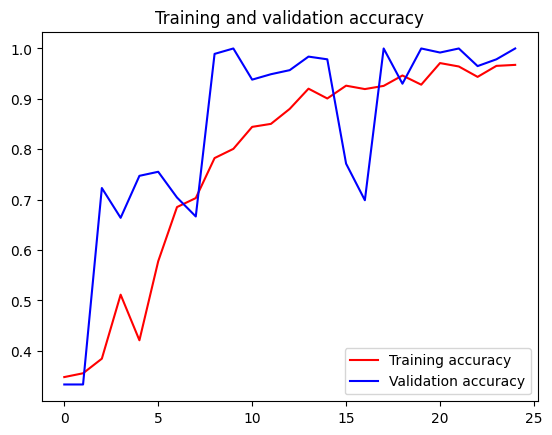

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()


plt.show()

In [15]:
import numpy as np # type: ignore
import tkinter as tk
from tkinter import filedialog
from keras.preprocessing import image # type: ignore

root = tk.Tk()
root.withdraw()  
file_path = filedialog.askopenfilename(title="Select Image")  # Chọn file ảnh

if file_path:  
    img = image.load_img(file_path, target_size=(150, 150))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)

    print("File:", file_path)
    print("Prediction:", classes)
else:
    print("No file selected!")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
File: /home/dang-minh-nguyen/Desktop/Repositories/Kaggle-Projects/RockPaperScissor/paperhand.jpg
Prediction: [[1. 0. 0.]]
